# Multimodel Incident Resolution on Arango

An incident-resolution agent on the Arango Contextual Data Platform. A fresh alert comes in and the agent does what a senior responder does: it forms the obvious hypothesis from vector similarity, tests it against the service topology, and **pivots to the real upstream root cause** when the alert is only a downstream symptom. One AQL query does vector search, a graph traversal, and two key-value joins (a per-service health signal and the on-call owner) in a single round trip; an AutoGraph knowledge graph over the runbooks then grounds a cited, natural-language fix.

**Prereqs:** `pip install -r requirements.txt`, and a `.env` with your Arango host/credentials + `OPENAI_API_KEY` + `GRAPHRAG_PROJECT`/`GRAPHRAG_DB` (see `.env.example`).

In [1]:
import sys
sys.path.insert(0, "src")   # the modules live in src/; run this notebook from the repo root

import json
from openai import OpenAI
from datasets import load_dataset

# Helpers live in src/ingest.py so the notebook and the scripts share one source of truth.
from ingest import connect, embed, EMBED_MODEL, EMBED_DIM, DATASET

db = connect()
oai = OpenAI()
topo = json.load(open("data/topology.json"))
print("connected:", db.name)

connected: incident_demo


## 1. Schema — one store, several shapes

A document collection for incidents (vector-indexed), a `services` + `service_depends_on` named graph for the topology, a `teams` collection for on-call ownership, a `service_signals` collection for live per-service health, and an `alerts` collection. (Re-run safe: we drop and recreate.)

In [2]:
if db.has_graph("service_topology"):
    db.delete_graph("service_topology")
for c in ["incidents", "services", "teams", "alerts", "service_depends_on", "service_signals"]:
    if db.has_collection(c):
        db.delete_collection(c)

incidents = db.create_collection("incidents")
services = db.create_collection("services")
teams = db.create_collection("teams")
alerts = db.create_collection("alerts")
signals = db.create_collection("service_signals")
graph = db.create_graph("service_topology")
graph.create_edge_definition(
    edge_collection="service_depends_on",
    from_vertex_collections=["services"],
    to_vertex_collections=["services"],
)
print("schema ready")

schema ready


## 2. Service topology, on-call teams + health signals

Hand-authored in `topology.json` and `service_signals.json` — the dataset ships no CMDB, so a small curated graph keeps the traversal legible, and the health signals stand in for live telemetry. In production these edges come from your real service map and the signals from your monitoring. Here `user-db` is flagged degraded (read-replica lag after a failover) so the agent has a real upstream fault to find.

In [3]:
services.insert_many([{"_key": k, **v} for k, v in topo["services"].items()])
teams.insert_many([{"_key": k, **v} for k, v in topo["teams"].items()])
db.collection("service_depends_on").insert_many(
    [{"_from": f"services/{a}", "_to": f"services/{b}"} for a, b in topo["depends_on"]]
)
sig = json.load(open("data/service_signals.json"))
signals.insert_many([{"_key": k, **v} for k, v in sig.items()])
print(f"{services.count()} services, {teams.count()} teams, "
      f"{db.collection('service_depends_on').count()} edges, {signals.count()} health signals")

12 services, 5 teams, 13 edges, 5 health signals


## 3. Tickets — load, embed, index

We pull `6StringNinja/synthetic-servicenow-incidents` (500 rows, MIT), embed `short_description + description`, keep the `resolution` text, and attach each incident to a service via its category. We also add four hand-authored synthetic seed incidents (`seed_incidents.json`) the public set lacks: a shallow "restart the leaf" decoy plus three `user-db` replica-lag cascades where the real fix was upstream. The vector index is created **after** the load so it trains on the full set; the alerts are embedded and indexed the same way.

In [4]:
ds = load_dataset(DATASET, split="train")
cat2svc = topo["category_to_service"]
vectors = embed(oai, [f'{r["short_description"]} {r["description"]}' for r in ds])

incidents.insert_many([
    {
        "_key": r["number"], "short_description": r["short_description"],
        "description": r["description"], "resolution": r["resolution"],
        "category": r["category"], "assignment_group": r["assignment_group"],
        "service": cat2svc.get(r["category"], "onboarding-api"), "embedding": v,
    }
    for r, v in zip(ds, vectors)
])

# Hand-authored synthetic precedents (the decoy + 3 user-db cascades).
seed = json.load(open("data/seed_incidents.json"))
seed_vecs = embed(oai, [f'{s["short_description"]} {s["description"]}' for s in seed])
incidents.insert_many([{**s, "embedding": v} for s, v in zip(seed, seed_vecs)])

incidents.add_index({
    "name": "incidents_vec", "type": "vector", "fields": ["embedding"],
    "params": {"metric": "cosine", "dimension": EMBED_DIM, "nLists": 10},
})

# Alerts: the live-signal shape, embedded + indexed so they are queryable too.
alert_docs = json.load(open("data/alerts.json"))
alert_vecs = embed(oai, [a["text"] for a in alert_docs])
alerts.insert_many([{**a, "embedding": v} for a, v in zip(alert_docs, alert_vecs)])
alerts.add_index({
    "name": "alerts_vec", "type": "vector", "fields": ["embedding"],
    "params": {"metric": "cosine", "dimension": EMBED_DIM, "nLists": 2},
})
print(f"{incidents.count()} incidents ({len(seed)} seeds) + {alerts.count()} alerts embedded + indexed")

504 incidents (4 seeds) + 8 alerts embedded + indexed


## 4. The multimodel query — four moves, one round trip

One AQL query (`resolver.py:MARQUEE`) does four things at once: `APPROX_NEAR_COSINE` (vector) finds similar incidents, `OUTBOUND ... GRAPH` (graph) expands the affected-service subgraph, a `DOCUMENT` lookup on `service_signals` over that subgraph (key-value) finds the degraded **upstream** dependency, and a `DOCUMENT` lookup on `teams` (key-value) returns the on-call owner of the real root cause. The `root_service` it returns is the deepest degraded upstream dependency when there is one — otherwise the alerting service itself.

In [5]:
from resolver import MARQUEE, resolve
print(MARQUEE)


LET similar = (
  FOR i IN incidents
    LET sim = APPROX_NEAR_COSINE(i.embedding, @vec)
    SORT sim DESC
    LIMIT 3
    RETURN {
      number: i._key,
      short_description: i.short_description,
      resolution: i.resolution,
      service: i.service,
      similarity: sim
    }
)
LET symptom = @service != null ? @service : FIRST(similar).service
LET affected = (
  FOR v, e, p IN 0..3 OUTBOUND CONCAT("services/", symptom) GRAPH "service_topology"
    COLLECT service = v._key, name = v.name AGGREGATE depth = MIN(LENGTH(p.edges))
    SORT depth
    RETURN {service, name, depth}
)
LET degraded = (
  FOR a IN affected
    FILTER a.depth > 0
    LET sig = DOCUMENT("service_signals", a.service)
    FILTER sig != null AND sig.status == "degraded"
    SORT a.depth DESC
    RETURN MERGE(a, {signal: sig.detail, observed_min_ago: sig.observed_min_ago})
)
LET root = LENGTH(degraded) > 0 ? FIRST(degraded).service : symptom
LET team = DOCUMENT("teams", DOCUMENT("services", root).team)
RETURN 

In [6]:
alert = json.load(open("data/alert.hero.json"))
payload = resolve(alert)
print(json.dumps(payload, indent=2))

{
  "symptom_service": "onboarding-api",
  "similar_incidents": [
    {
      "number": "INC-SEED-ESIGN-1",
      "short_description": "Merchants unable to e-sign the Merchant Agreement; onboarding stuck at the document step with a permission error in the UI",
      "resolution": "Restarted onboarding-api pods and invalidated the merchant permission cache; the e-sign step recovered. Closed as an onboarding-api permission-cache issue.",
      "service": "onboarding-api",
      "similarity": 0.9001772999763489
    },
    {
      "number": "INC00311",
      "short_description": "Merchant unable to e-sign agreement",
      "resolution": "The network team identified a routing issue causing the intermittent connections and resolved it by optimizing the network configuration to ensure stable and uninterrupted service.",
      "service": "auth-service",
      "similarity": 0.8412749767303467
    },
    {
      "number": "INC00469",
      "short_description": "Access Rights Restriction",
      

The alert fired on `onboarding-api`, but `pivoted` is `true`: the query found `user-db` degraded two hops upstream and set it as the `root_service`, so the on-call owner is Identity, not Onboarding. Vector similarity alone would have stopped at the most similar incident and pointed at the wrong service. Next, the agent makes that reasoning explicit.

## 5. The agent reasons, it doesn't just retrieve

`reason()` runs the full pass: it records the **obvious** vector-only hypothesis, tests it against the dependency graph and the health signals, **pivots** to the degraded upstream root cause, pulls **structural precedents** with a second vector pass scoped to that root, **eliminates** the wrong hypothesis, grounds the fix in the cited runbook, and returns a confidence verdict plus a human-verification command.

In [7]:
from resolver import reason

reasoned = reason(alert)
ob = reasoned["obvious_hypothesis"]
rc = reasoned["root_cause"]
print("OBVIOUS (vector-only):", ob["fix"][:80])
print("   basis:", ob["basis"], "| would page:", ob["paged"])
print()
print("ROOT CAUSE (agent):", rc["service"], f"({rc['depth']} hops upstream)")
print("   signal:", rc["signal"])
print("   pages:", rc["on_call"]["team"], "| confidence:", reasoned["confidence"])
print()
print("PRECEDENTS:", [p["number"] for p in reasoned["precedents"]])
print("ELIMINATED:", reasoned["eliminated"]["reason"])
print()
print("VERIFY FIRST:", reasoned["verify_command"])

OBVIOUS (vector-only): Restarted onboarding-api pods and invalidated the merchant permission cache; the
   basis: INC-SEED-ESIGN-1 @ 0.9 | would page: Onboarding On-Call

ROOT CAUSE (agent): user-db (2 hops upstream)
   signal: read_replica_lag 8.4s after primary failover 14m ago
   pages: Identity On-Call | confidence: high

PRECEDENTS: ['INC-SEED-UDB-2', 'INC-SEED-UDB-1', 'INC-SEED-UDB-3']
ELIMINATED: 3 past user-db incidents resolved upstream; restarting the onboarding-api tier did not help. The degraded dependency is user-db (read_replica_lag 8.4s after primary failover 14m ago), 2 hops upstream of the alert.

VERIFY FIRST: psql -h user-db-replica -c "SELECT now() - pg_last_xact_replay_timestamp() AS replica_lag;"  # if > 5s, route reads to the primary -- do NOT restart the onboarding tier


The reasoning chain, the three-way ablation (vector-only is wrong, graph+key-value finds the right root but no fix, the full multimodel query is right and cited), and the Frankenstack-vs-one-query contrast — rendered from this run:

wrote assets/reasoning-chain.png
wrote assets/ablation.png


wrote assets/affected-subgraph.png


wrote assets/polyglot-vs-aql.png


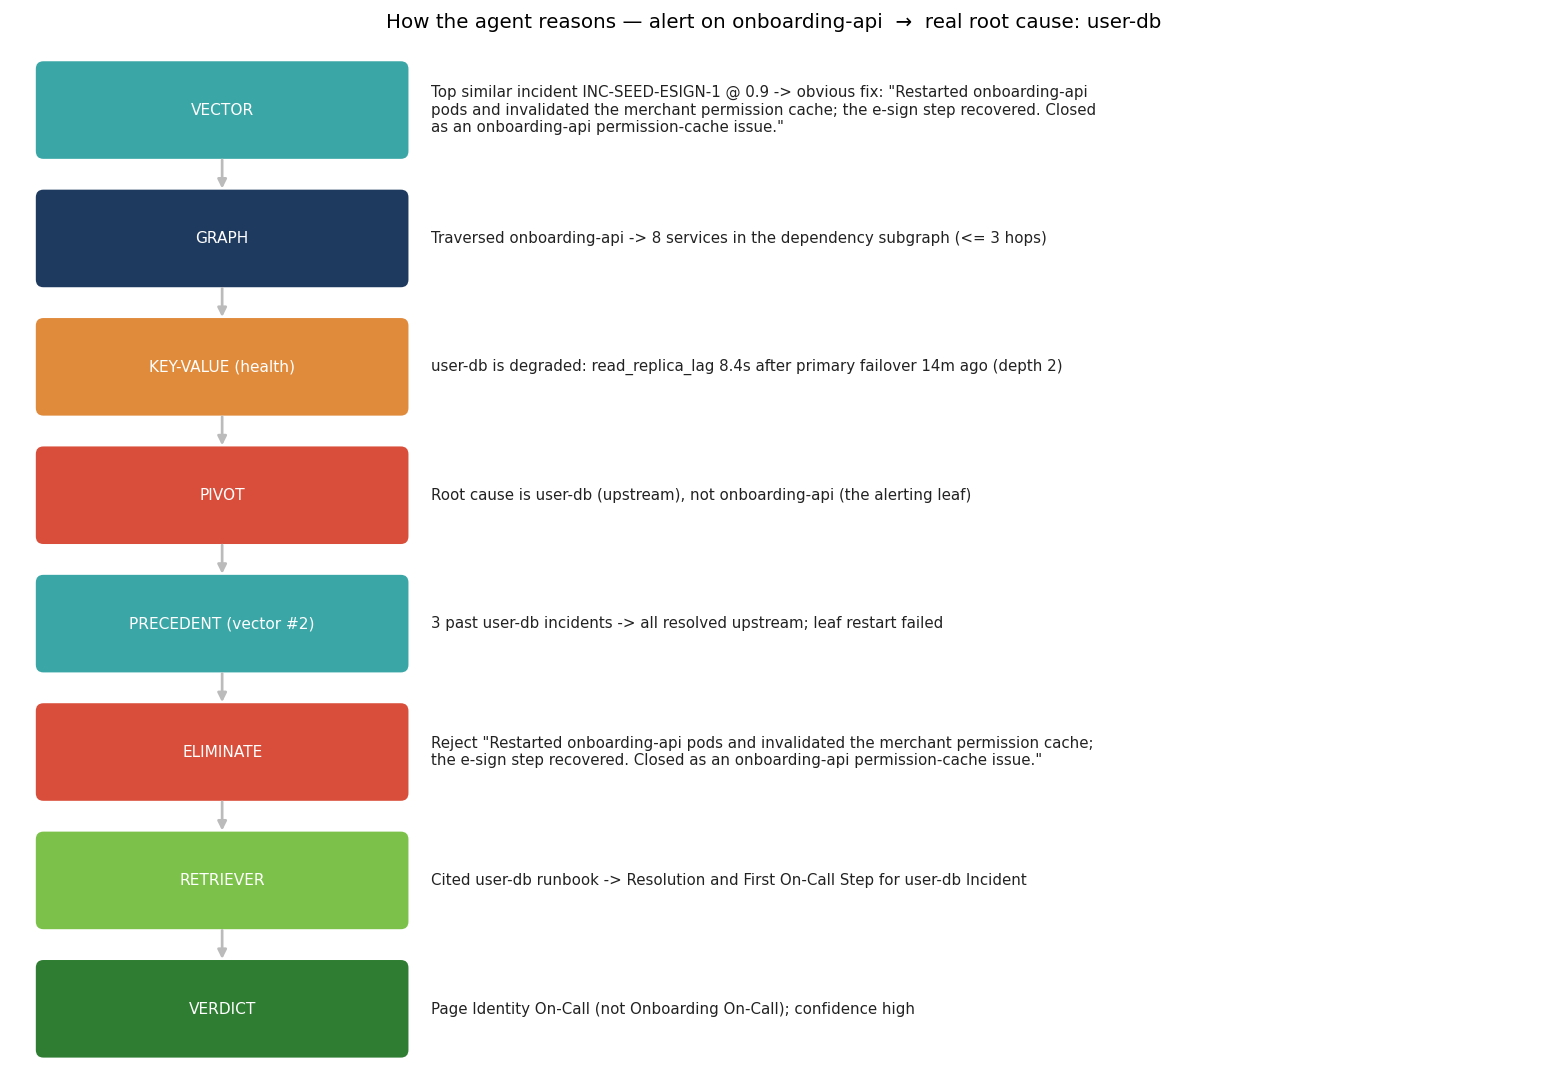

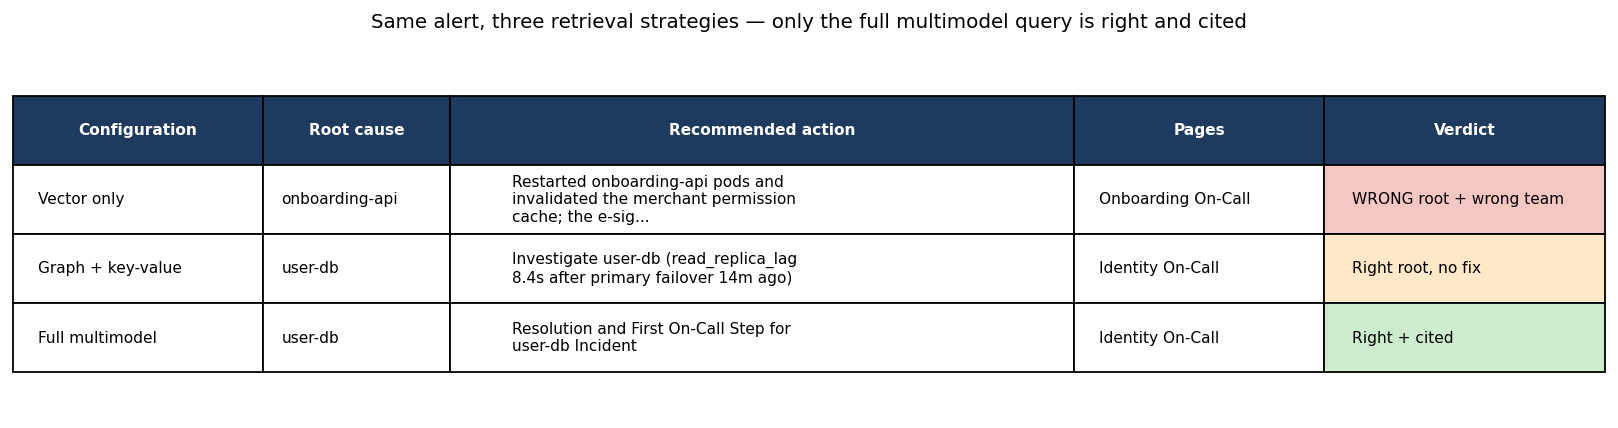

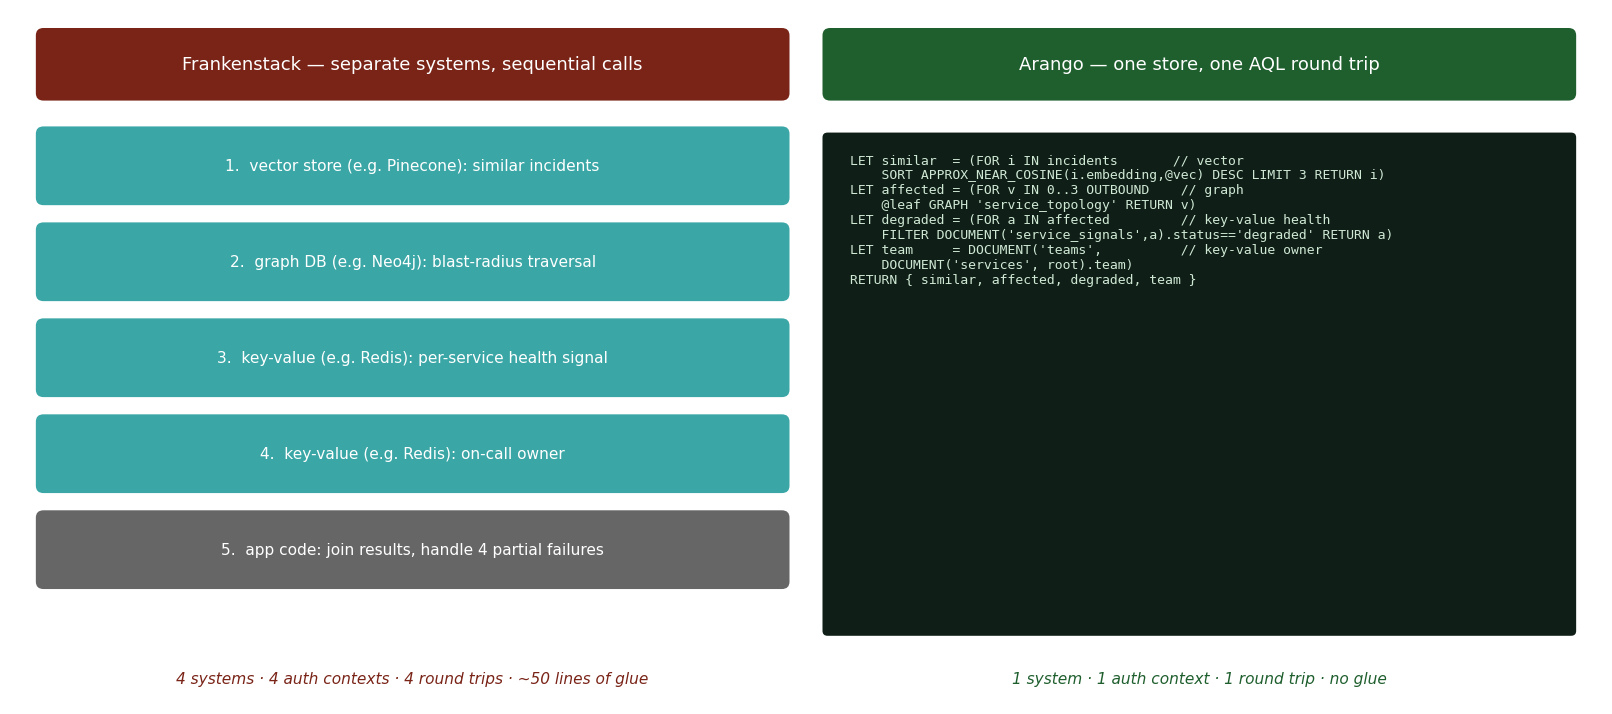

In [8]:
import viz
from IPython.display import Image, display

viz.cascade_figures(reasoned=reasoned)   # reasoning chain, ablation, polyglot, cascade subgraph
display(Image("assets/reasoning-chain.png"))
display(Image("assets/ablation.png"))
display(Image("assets/polyglot-vs-aql.png"))

## 6. The runbook knowledge graph (AutoGraph)

The structured payload says *what* broke and *who* owns it. To say *how to fix it* in grounded prose, AutoGraph reads the runbooks in `data/runbooks/`, discovers the knowledge domains, and builds a knowledge graph — entities, relations, communities, and chunk embeddings — queried through the project's Retriever. Most of the pipeline is scriptable over AutoGraph's REST API (`graphrag_ingest.py`): import → corpus build → RAG strategizer. The final orchestration (the entity build) is one click in the web UI ("Continue to Import"), since the REST `/orchestrate` endpoint builds nothing on this platform version. The AutoGraph project itself is also created once in the UI (which deploys its control + retriever services); service postfixes are discovered at runtime in `graphrag.py`, never hardcoded.

In [9]:
import graphrag_ingest
graphrag_ingest.main()  # skip-if-built; pass --reset on the CLI to rebuild

from graphrag import GRAPHRAG_PROJECT, kg_db
kdb = kg_db()
for c in ["Documents", "Entities", "Relations", "Communities"]:
    print(f"{c:12}", kdb.collection(f"{GRAPHRAG_PROJECT}_{c}").count())

KG already built (skip; pass --reset to rebuild).
KG verification:


  incidents-runbook-autograph_Documents: 11
  incidents-runbook-autograph_Chunks: 11


  incidents-runbook-autograph_Entities: 105


  incidents-runbook-autograph_Communities: 5


  incidents-runbook-autograph_Relations: 227
  PASS: True


Documents    11
Entities     105
Relations    227


Communities  5


## 7. The cited, grounded answer

`answer()` (called inside `reason()`) queries the Retriever's Unified Search (`query_type 3`) and grounds the next step in the **exact** root-cause runbook the AQL query pinpointed (primary citation, matched on the runbook's content), then appends the related blast-radius runbooks. `corroborated()` independently checks that a cited runbook references the root or an affected service — the precise AQL surface and the semantic Retriever surface converging on the same incident.

In [10]:
cited = reasoned["cited_answer"]
print(cited["text"], "\n")
for k, c in cited["citations"].items():
    tag = " (primary)" if c.get("primary") else ""
    label = c.get("file_name") or c.get("chunk_id") or "?"
    print(f"[{k}]{tag} {label}")
print("\ncorroboration:", reasoned["corroboration"])

## Resolution and First On-Call Step for user-db Incident

### Context
During a user-db incident, where there is a read-replica lag of 8.4 seconds after a primary failover occurring 14 minutes ago, downstream services report issues such as stale reads and permission errors. This scenario is classified as a P2 incident due to lag causing read inconsistencies but not outright failures [1].

### Recommended Resolution Steps
Based on the user-db runbook, the resolution for issues stemming from a replica failover involves the following actions:

1. **Route Critical Reads to Primary:**
   - The immediate action shall be to route critical reads, particularly for services like the auth-service that depend on fresh data, to the primary instance. Doing so will ensure that the sensitive operations continue to get up-to-date information even as the replica catches up [1].

2. **Monitor and Revert:**
   - Once the replication lag has decreased and is stable, confirmed by bringing `user_db_replica_l

## 8. Results across the alert set

The whole alert estate, end to end. `evaluate()` runs every alert in `data/alerts.json` through the multimodel query + the cited answer and times both halves. For each alert the table shows the alerting service, whether the agent **pivoted** to an upstream root cause, the blast radius, the on-call owner, the runbook it grounded on, and whether the two surfaces corroborate.

The headline: several alerts turn out to be the same hidden root cause masquerading as different services, every alert grounds on the correct runbook, and the multimodel query itself returns in a few hundred milliseconds.

In [11]:
import pandas as pd
from resolver import evaluate

alerts_in = json.load(open("data/alerts.json"))
results = evaluate(alerts_in)              # one row per alert, both timings captured
results_table = pd.DataFrame(results)

total = len(results_table)
pivoted = int(results_table["pivoted"].sum())
grounded = int(results_table["grounded"].sum())
corroborated_count = int(results_table["corroborated"].sum())
median_query_ms = results_table["query_ms"].median()

print(f"{pivoted}/{total} pivoted to an upstream root cause    "
      f"{grounded}/{total} grounded    {corroborated_count}/{total} corroborated    "
      f"median multimodel query {median_query_ms:.0f} ms")

shown = results_table.assign(
    pivoted=results_table["pivoted"].map({True: "✓", False: ""}),
    grounded=results_table["grounded"].map({True: "✓", False: "✗"}),
    corroborated=results_table["corroborated"].map({True: "✓", False: "✗"}),
)
shown[["alert", "service", "symptom_service", "root_service", "pivoted",
       "blast_radius", "on_call", "primary_runbook", "grounded", "corroborated",
       "query_ms", "answer_s"]]

4/8 pivoted to an upstream root cause    8/8 grounded    8/8 corroborated    median multimodel query 173 ms


,alert,service,symptom_service,root_service,pivoted,blast_radius,on_call,primary_runbook,grounded,corroborated,query_ms,answer_s
0,ALR-001,onboarding-api,onboarding-api,user-db,✓,8,Identity On-Call,user-db-replica-lag.md,✓,✓,660.8,6.5
1,ALR-002,payment-gateway,payment-gateway,payment-gateway,,2,Payments On-Call,payment-gateway-declines.md,✓,✓,822.2,7.4
2,ALR-003,auth-service,auth-service,user-db,✓,2,Identity On-Call,user-db-replica-lag.md,✓,✓,378.5,6.0
3,ALR-004,network-gateway,network-gateway,network-gateway,,1,Platform On-Call,network-gateway-egress-saturation.md,✓,✓,180.0,8.2
4,ALR-005,user-db,user-db,user-db,,1,Identity On-Call,user-db-replica-lag.md,✓,✓,138.5,8.5
5,ALR-006,document-service,document-service,document-service,,2,Onboarding On-Call,document-service-degraded.md,✓,✓,145.0,5.8
6,ALR-007,merchant-service,merchant-service,user-db,✓,5,Identity On-Call,user-db-replica-lag.md,✓,✓,150.6,9.2
7,ALR-008,api-gateway,api-gateway,user-db,✓,10,Identity On-Call,user-db-replica-lag.md,✓,✓,165.3,7.4


wrote assets/results.png (8/8 grounded, 8/8 corroborated)


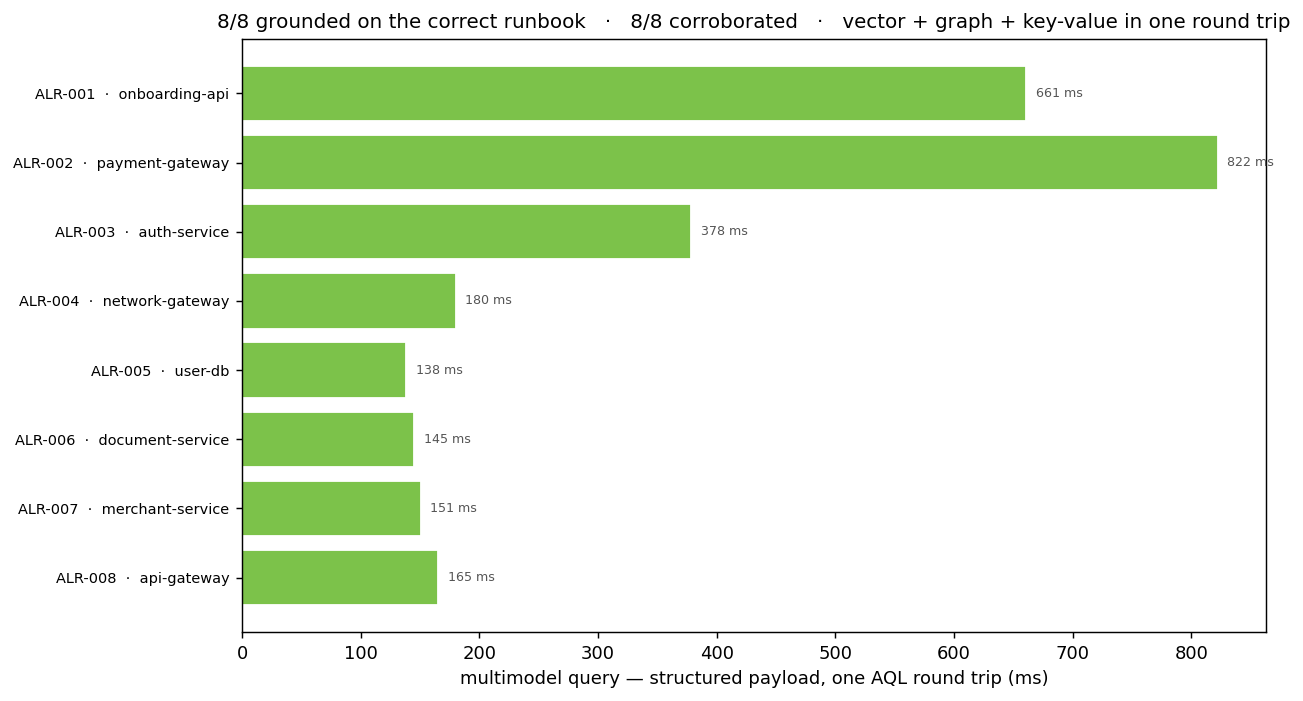

In [12]:
viz.fig_results_from_rows(results)
display(Image("assets/results.png"))

### Figures

The cascade subgraph for the headline alert (alerting leaf in amber, real root cause in red) and the runbook knowledge graph, rendered straight from the live deployment.

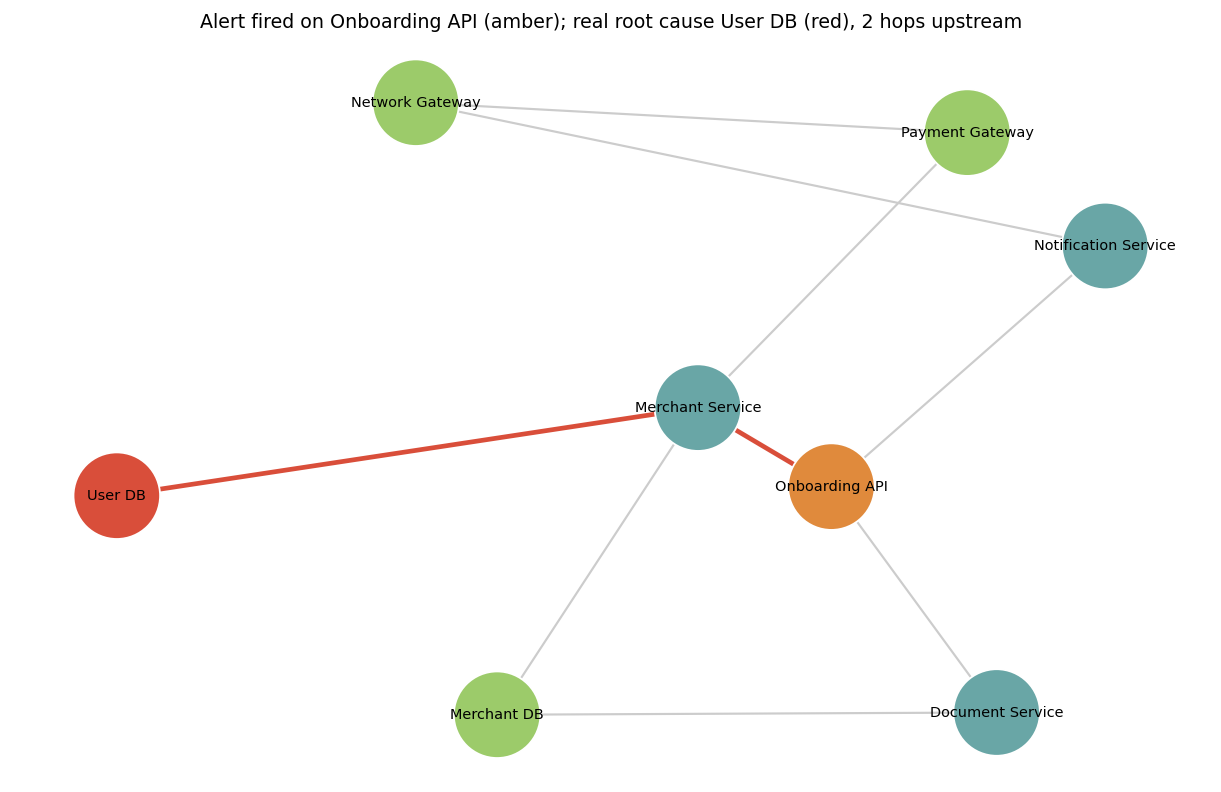

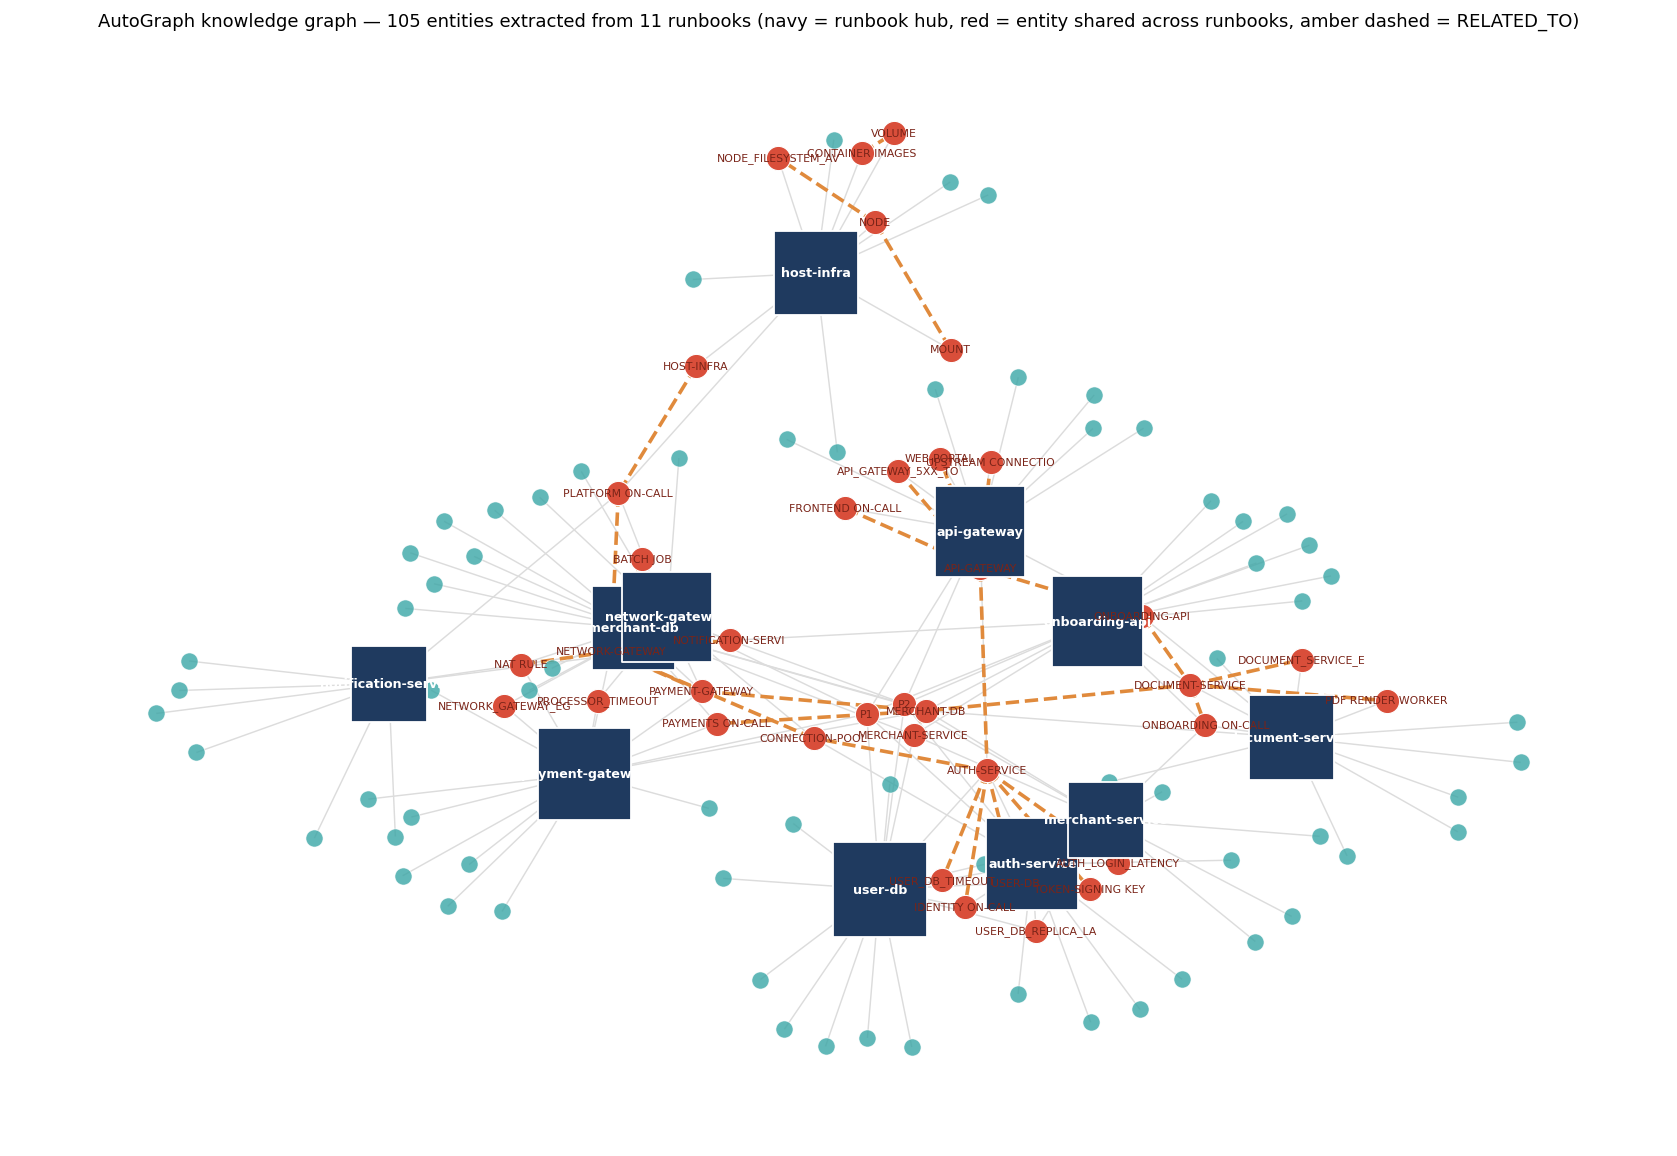

In [13]:
display(Image("assets/affected-subgraph.png"))
display(Image("assets/knowledge-graph.png"))

## What this shows

One Arango Contextual Data Platform deployment resolves an operational alert end to end — and it **reasons** about it rather than returning the first similar hit. Vector + graph + two key-value joins in a single AQL round trip surface the degraded upstream dependency the alert was only a symptom of; a second vector pass supplies the structural precedent; and an AutoGraph knowledge graph grounds the cited fix, with an independent corroboration check. No separate vector store, graph database, or retrieval service to stitch together. Scale knobs (ticket slice, runbook count) and extension points (LangChain / LangGraph, Arango's **Ada** assistant) are documented in the README.